<a href="https://colab.research.google.com/github/Kotyga/ML_toolkit/blob/main/activation_func.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from scipy import special
import math
import matplotlib.pyplot as plt
from itertools import product

In [2]:
def print_pic(func, x, params=None, figsize=(9, 6), title=None, ax=None):

    x = np.asarray(x, dtype=float)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    params = params or {}

    if params:
        parameter_names = list(params)
        parameter_values = [
            value if isinstance(value, (list, tuple, np.ndarray)) else [value]
            for value in params.values()
        ]

        combinations = product(*parameter_values)

        for values in combinations:
            kwargs = dict(zip(parameter_names, values))

            y = func(x.copy(), **kwargs)

            label = ", ".join(
                f"{name}={value:g}" if isinstance(value, (int, float))
                else f"{name}={value}"
                for name, value in kwargs.items()
            )

            ax.plot(x, y, linewidth=2, label=label)
    else:
        y = func(x.copy())
        ax.plot(x, y, linewidth=2, label=func.__name__)

    ax.spines["left"].set_position(("data", 0))
    ax.spines["bottom"].set_position(("data", 0))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(1)
    ax.spines["bottom"].set_linewidth(1)

    ax.set_axisbelow(True)
    ax.grid(
        True,
        which="both",
        linestyle="--",
        linewidth=0.5,
        alpha=0.5
    )

    ax.legend(title=func.__name__)
    ax.set_title(title or f"Активационная функция: {func.__name__}")
    ax.margins(x=0.02)

    return fig, ax

In [3]:
def sigmoid(x):
    x = np.asarray(x, dtype=float)
    return 1/(1 + np.exp(-x))

In [4]:
def leaky_relu(x, alpha=0.01):
    x = np.asarray(x, dtype=float)
    return np.where(x >= 0, x, alpha * x)

In [5]:
def softmax(x):
    x = np.asarray(x, dtype=float)
    shifted_x = x - np.max(x, axis=-1, keepdims=True)
    exp_x = np.exp(shifted_x)

    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

In [6]:
def gelu(x):
    correct = 2 ** -0.5
    x = np.asarray(x, dtype=float)
    return 0.5 * x * (1 + special.erf(x * correct))

In [7]:
def relu(x):
    x = np.asarray(x, dtype=float)
    return np.maximum(x, 0)

In [8]:
def tanh(x):
    x = np.asarray(x, dtype=float)
    return (np.exp(x) - np.exp(-x))/(np.exp(x) + np.exp(-x))

In [9]:
def selu(x, lam=1.0507009873554804934193349852946, alpha=1.6732632423543772848170429916717):
    x = np.asarray(x, dtype=float)
    return lam * np.where(
        x > 0,
        x,
        alpha * (np.exp(x) - 1)
    )

In [10]:
def elu(x, alpha):
    x = np.asarray(x, dtype=float)
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))

In [11]:
def swish(x):
    """
    Implement Swish activation function.
    """
    x = np.asarray(x, dtype=float)
    return x * sigmoid(x)

In [12]:
x = np.linspace(-10, 10, num=50)

(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'center': 'Активационная функция: sigmoid'}>)

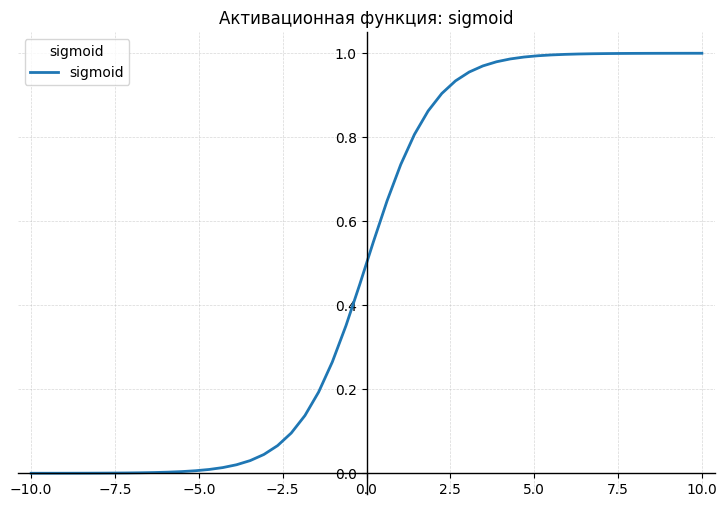

In [13]:
print_pic(sigmoid, x)

(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'center': 'Активационная функция: softmax'}>)

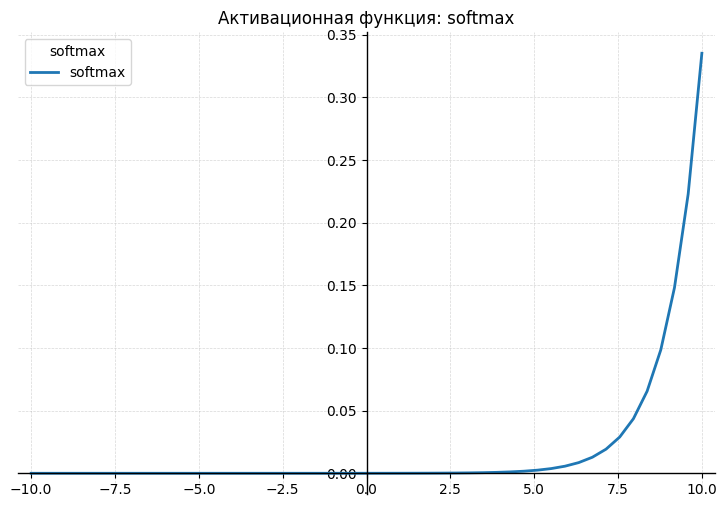

In [14]:
print_pic(softmax, x)

(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'center': 'Активационная функция: gelu'}>)

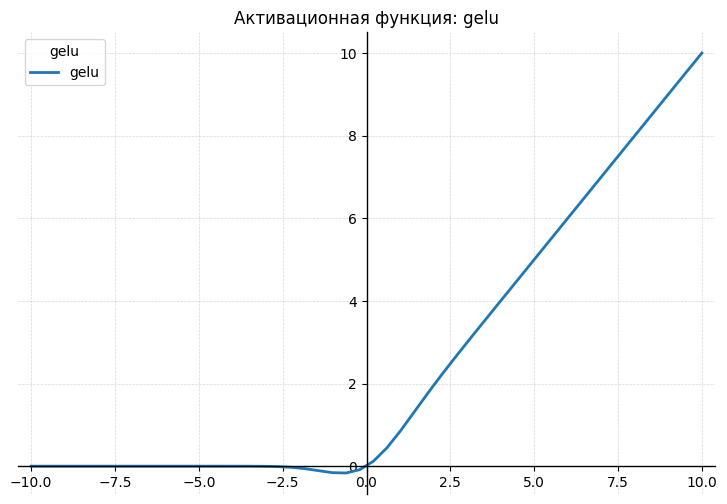

In [15]:
print_pic(gelu, x)

(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'center': 'Активационная функция: relu'}>)

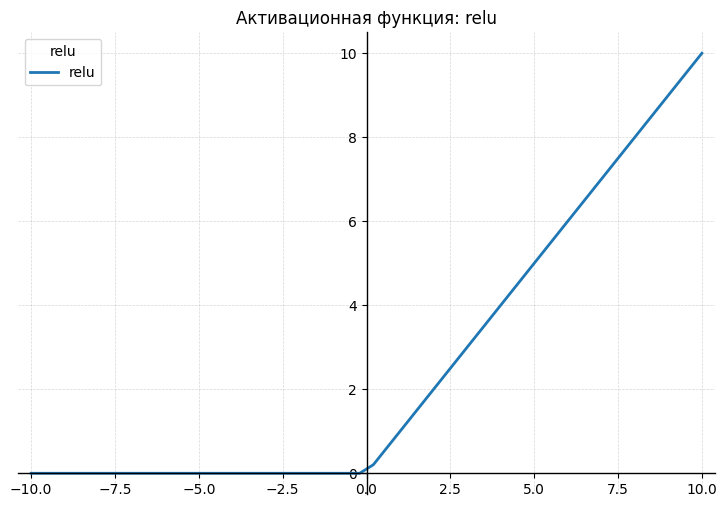

In [16]:
print_pic(relu, x)

(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'center': 'Активационная функция: elu'}>)

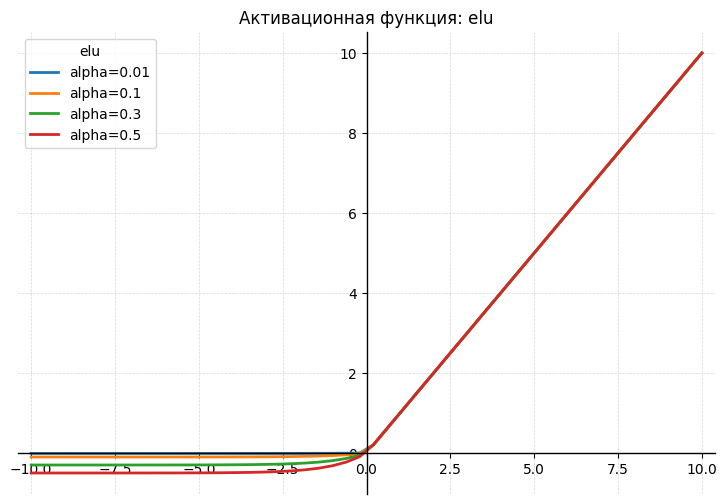

In [17]:
print_pic(elu, x,
          params={
        "alpha": [0.01, 0.1, 0.3, 0.5]
    })

(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'center': 'Активационная функция: swish'}>)

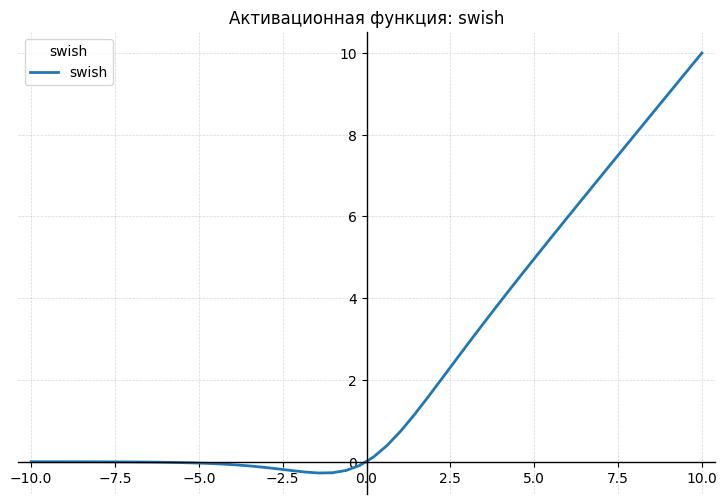

In [18]:
print_pic(swish, x)

(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'center': 'Активационная функция: tanh'}>)

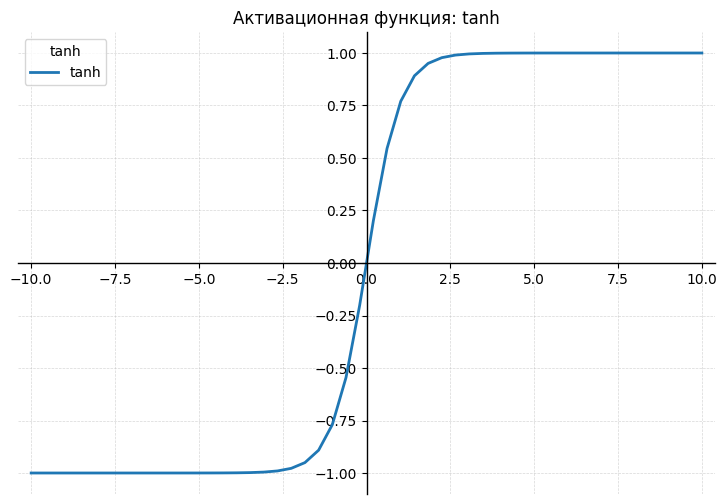

In [19]:
print_pic(tanh, x)

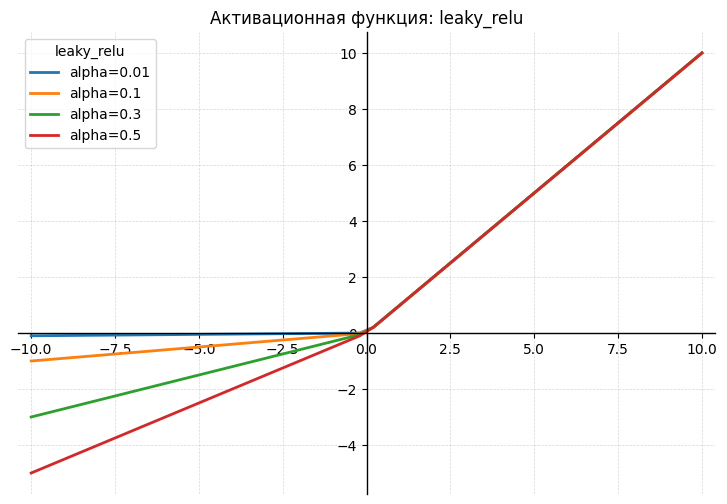

In [20]:
print_pic(
    leaky_relu,
    x,
    params={
        "alpha": [0.01, 0.1, 0.3, 0.5]
    }
)
plt.show()

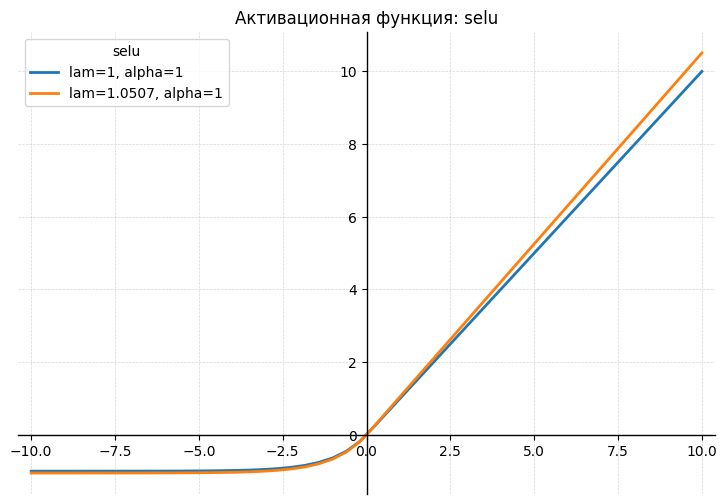

In [21]:
print_pic(
    selu,
    x,
    params={
        "lam": [1.0, 1.0507],
        "alpha": [1.0]
    }
)
plt.show()

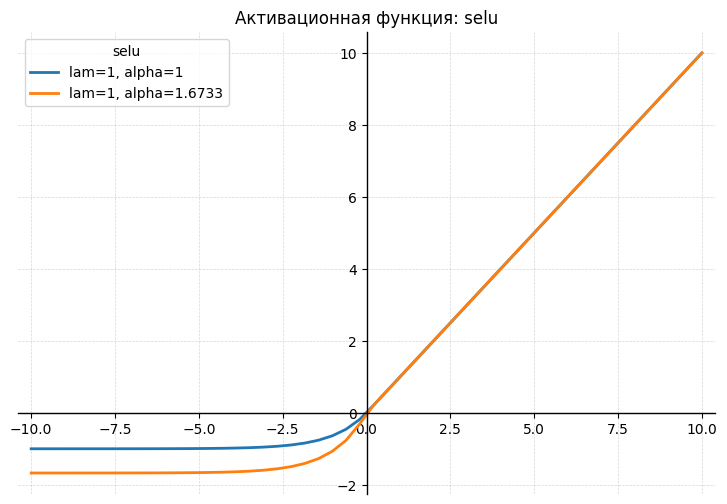

In [22]:
print_pic(
    selu,
    x,
    params={
        "lam": [1.0],
        "alpha": [1.0, 1.6733]
    }
)
plt.show()

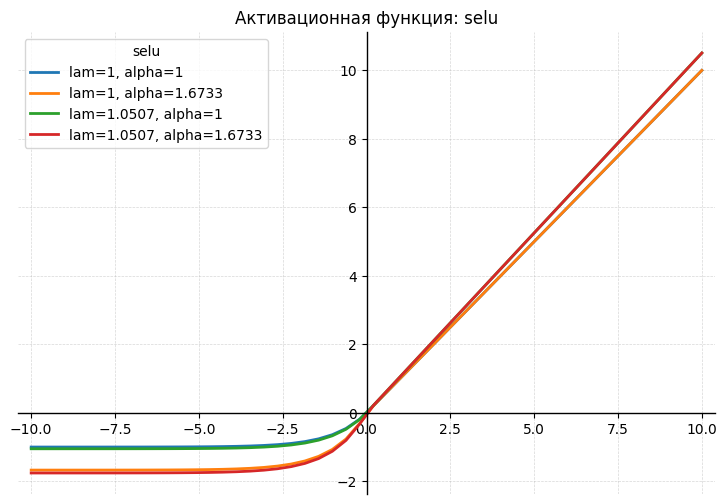

In [23]:
print_pic(
    selu,
    x,
    params={
        "lam": [1.0, 1.0507],
        "alpha": [1.0, 1.6733]
    }
)
plt.show()